# Decorrelation Scale Dependences Ensemble Analysis

**Purpose**: Code for explore the factors impacting of decorrelation scale estimates. Here, the focus is on the impact of record length and spectral slope. 

**Luke Colosi | lcolosi@ucsd.edu**

Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from scipy.signal import detrend
from scipy.integrate import trapezoid
from datetime import datetime, timedelta
import cmocean.cm as cmo

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from spectra import generate_powerlaw_data
from autocorr import windowed_decorrelation_scale
from plotScaleAnalysis import add_corner_label
from lsf import unweighted_lsf

Set plotting parameters

In [2]:
fontsize = 16
PATH_figs   = ROOT + 'AirSeaCoupling/figs/paper_figures/'
colors = ['#4c72b0', '#55a868', '#c44e52', "#b2ae72"] 
colors_decor = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,                          # Fontsize
    "text.usetex": True,                           # Use LaTeX for all text
    "font.family": "serif",                         # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

### **Section 1**: Compute decorrelation scale as a function of record length 

Set analysis parameters

In [3]:
# Set time parameters
dt = 1                              # Time interval (hours)
T  = 2*365*24                       # Duration of record (hours) 
N  = int(T/dt)                      # Number of data points in our record
random_seed = np.arange(42,52+1,1)  # Set random seed for each ensemble member
n_seed = len(random_seed)           # Number of ensemble members

# Set power-law parameters
alpha_ws = np.array([1, 1.5,2,3])  # Prescribed spectral slopes
n_alpha = len(alpha_ws)            # Number of spectral slopes 

# Set windowing parameters
overlap = 0.5                  # Fractional overlap between windows
min_window = 300               # Minimum window length (number of data points, 100 points ~ 4 days)
max_divisor = N // min_window  # The largest n such that N/n >= 100

# Generate divisors (fractions of the total length): 2, 3, 4, ..., max_divisor
divisors = np.arange(2, max_divisor + 1)

# Calculate window sizes directly using integer division (//) to ensure they are integers
window_sizes = N // divisors

# Filter for range (if necessary) 
window_sizes = window_sizes[window_sizes >= min_window]

# Remove duplicates
window_sizes = np.unique(window_sizes)[::-1]  # Unique and sorted largest to smallest
n_windows = len(window_sizes)  # Number of window lengths

Generate time series and compute decorrelation scales 

In [4]:
# Initialize arrays
Lt_av   = np.zeros((n_seed, n_alpha, n_windows))
Lt_stdm = np.zeros((n_seed, n_alpha, n_windows))

# Loop through spectral slopes
for i, ialpha in enumerate(alpha_ws):

    # Set progress bar
    progress = (i+1) / (n_alpha)
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Loop through random seeds
    for j, iseed in enumerate(random_seed):

        # Generate simulation data 
        t, x, f, psd = generate_powerlaw_data(N=N, alpha=ialpha, random_state=iseed, dt=dt)

        # Preform scale analysis
        scales, Lt_mean, Lt_err, _ = windowed_decorrelation_scale(x, t, dt, scales=window_sizes, norm=False, 
                                                                        overlap=overlap, return_windows=True, 
                                                                        valid_frac=0.8, detrend_option=True)
        
        # Store results 
        Lt_av[j, i, :]   = Lt_mean
        Lt_stdm[j, i, :] = Lt_err

    # Convert units of frequency and time
    f_cpd = f * 24
    t_year = t * (1/24)*(1/365)

# Compute ensemble mean and std dev
Lt_av_ens   = np.mean(Lt_av, axis=0)
Lt_stdm_ens = np.mean(Lt_stdm, axis=0)

Progress: 100.0%

Clean up decorrelation scale estimates

In [5]:
# Set zero decorrelation scales to masked data
mask = (Lt_av_ens == 0)
Lt_av_ens   = np.ma.array(Lt_av_ens, mask=mask)
Lt_stdm_ens = np.ma.array(Lt_stdm_ens, mask=mask)

# Convert decorrelation scales to units of days and window size to months
Lt_av_days_ws = Lt_av_ens * (1/24)
Lt_stdm_days_ws = Lt_stdm_ens * (1/24)
window_sizes_months_ws = window_sizes / (24 * 30.44)

Plot decorrelation scale estimates

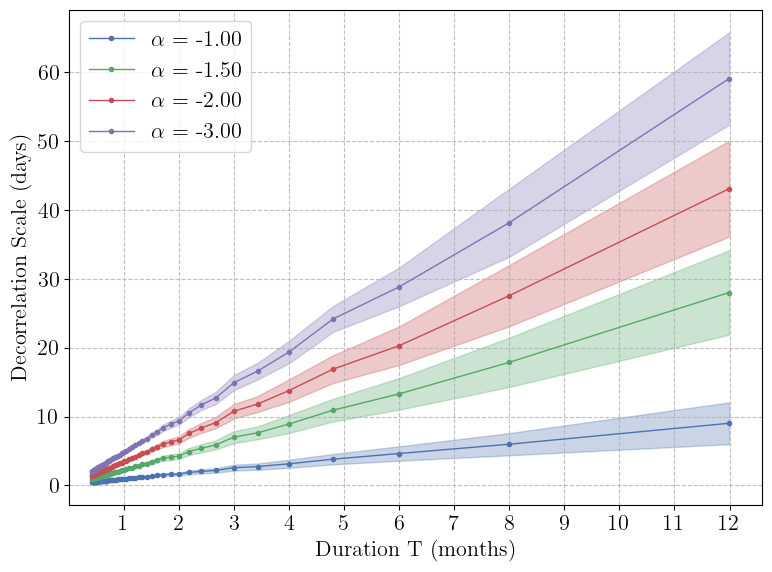

In [6]:
# Set color counter
cn = 0

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through spectral slopes
for i, alpha in enumerate(alpha_ws):
    
    # Plot just spectral slopes of 1, 1.5, 2, and 3
    if (alpha == 1) | (alpha == 1.5) | (alpha == 2) | (alpha == 3): 

        # Plot mean decorrelation scale
        ax.plot(window_sizes_months_ws, Lt_av_days_ws[i, :], '.-', color=colors_decor[cn],
                linewidth=1, label=r'$\alpha$ = -{:.2f}'.format(alpha))
        
        # Plot standard error as shaded region
        ax.fill_between(window_sizes_months_ws,
                        Lt_av_days_ws[i, :] - Lt_stdm_days_ws[i, :],
                        Lt_av_days_ws[i, :] + Lt_stdm_days_ws[i, :],
                        color=colors_decor[cn], alpha=0.3)

        # Reset counter 
        cn += 1

# Set figure attributes
ax.set_xlabel('Duration T (months)')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xlim(0, np.max(window_sizes_months_ws) * 1.05)
ax.set_xticks(np.arange(1,13))
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(loc='upper left', fontsize=fontsize)

# Display figure
plt.tight_layout()
plt.show()

### **Section 2**: Compute decorrelation scale as a function of spectral slope

Set analysis parameters

In [7]:
# Set time parameters
dt = 1                # Time interval (hours)
T  = 2*365*24         # Duration of record (hours) 
N  = int(T/dt)        # Number of data points in our record
random_seed = np.arange(42,52+1,1)  # Set random seed for each ensemble member
n_seed = len(random_seed)           # Number of ensemble members

# Set power-law parameters
alphas_as = np.arange(0,5 + 0.1,0.1)  # Prescribed spectral slopes
n_alpha = len(alphas_as)              # Number of spectral slopes

# Set windowing parameters
overlap = 0.5                                                 # Fractional overlap between windows
window_sizes = np.int64(np.array([3, 6, 8, 12]) * 30.44* 24)  # Units: Hours (or number of data points in the record)
n_windows = len(window_sizes)

Generate time series and compute decorrelation scales 

In [8]:
# Initialize arrays
Lt_av   = np.zeros((n_seed,n_alpha, n_windows))
Lt_stdm = np.zeros((n_seed, n_alpha, n_windows))

# Loop through spectral slopes
for i, ialpha in enumerate(alphas_as):

    # Set progress bar
    progress = (i+1) / (len(alphas_as))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Loop through random seeds
    for j, iseed in enumerate(random_seed):

        # Generate fake data 
        t, x, f, psd = generate_powerlaw_data(N=N, alpha=ialpha, random_state=iseed, dt=dt)

        # Preform scale analysis
        scales, Lt_mean, Lt_err, _ = windowed_decorrelation_scale(x, t, dt, scales=window_sizes, norm=False, 
                                                                        overlap=overlap, return_windows=True,
                                                                        valid_frac=0.8, detrend_option=True)
    
        # Store results (Lt_mean and Lt_std are 1D arrays of length n_windows)
        Lt_av[j, i, :]   = Lt_mean
        Lt_stdm[j, i, :] = Lt_err

# Compute ensemble mean and std dev
Lt_av_ens   = np.mean(Lt_av, axis=0)
Lt_stdm_ens = np.mean(Lt_stdm, axis=0)

Progress: 100.0%

Clean up decorrelation scale estimates

In [9]:
# Set zero decorrelation scales to masked data
mask = (Lt_av_ens == 0)
Lt_av_ens   = np.ma.array(Lt_av_ens, mask=mask)
Lt_stdm_ens = np.ma.array(Lt_stdm_ens, mask=mask)

# Convert decorrelation scales to units of days and window size to months
Lt_av_days_as = Lt_av_ens * (1/24)
Lt_stdm_days_as = Lt_stdm_ens * (1/24)
window_sizes_months_as = window_sizes / (24 * 30.44)

Plot the results

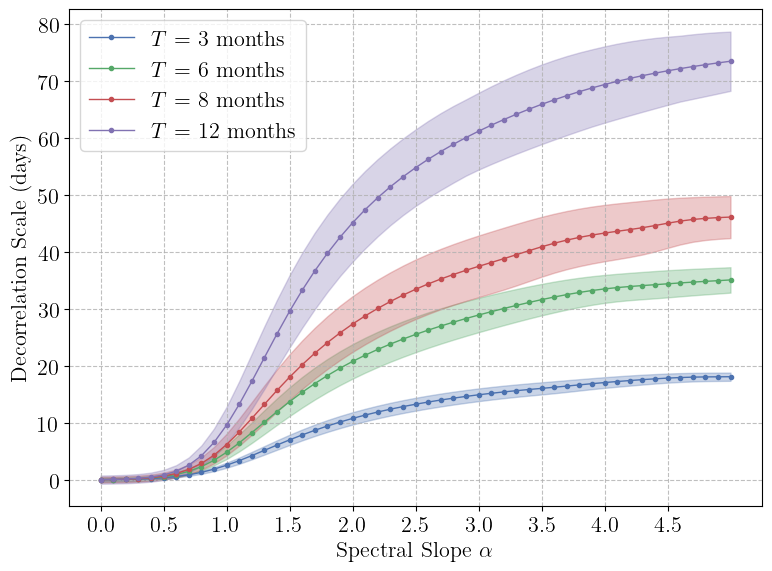

In [10]:
# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through window sizes
for i, window in enumerate(window_sizes_months_as):

    # Plot mean decorrelation scale
    ax.plot(alphas_as, Lt_av_days_as[:,i], '.-', color=colors_decor[i],
            linewidth=1, label=r'$T$ = {:.0f} months'.format(window))
    
    # Plot standard error as shaded region
    ax.fill_between(alphas_as,
                     Lt_av_days_as[:,i] - Lt_stdm_days_as[:,i],
                     Lt_av_days_as[:,i] + Lt_stdm_days_as[:,i],
                     color=colors_decor[i], alpha=0.3)

# Set figure attributes
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xticks(np.arange(0,5,0.5))
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(loc='upper left', fontsize=fontsize)

# Display figure
plt.tight_layout()
plt.show()

Save slice data into a npz file

In [11]:
# Set the path to direction for saving data 
PATH = ROOT + 'AirSeaCoupling/data/synthetic/'

# Set file path and name
file_path = PATH + "decorrelation_window_size_fit_slice.npz"

# Remove file if file already exists
if os.path.exists(file_path):
    os.remove(file_path)

# Set metadata
metadata = {
    'description': 'Temporal decorrelation scales from idealized simulations of red spectra with prescribed spectral slope. ',
    'source': 'Synthetic data (2 years of hourly data) ensemble avergaed over 10 random seeds.',
    'coordinates units': '1 hr'
}

# Save data arrays and metadata to a .npz file
np.savez(file_path, 
        Lt_av_as       = Lt_av_days_as,         # Units: days 
        Lt_stdm_as     = Lt_stdm_days_as,       # Units: days
        Lt_av_ws       = Lt_av_days_ws,         # Units: days 
        Lt_stdm_ws     = Lt_stdm_days_ws,       # Units: days
        scales_as      = window_sizes_months_as, # Units: months
        scales_ws      = window_sizes_months_ws, # Units: months
        alphas_as      = alphas_as,
        alphas_ws      = alpha_ws,
        metadata       = metadata
        )

### **Section 3**: Compute decorrelation scale as a function of both record length and spectral slope

Set analysis parameters

In [19]:
# Set time parameters
dt = 1                # Time interval (hours)
T  = 2*365*24         # Duration of record (hours) 
N  = int(T/dt)        # Number of data points in our record
random_seed = np.arange(42,52+1,1)  # Set random seed for each ensemble member
n_seed = len(random_seed)           # Number of ensemble members

# Set power-law parameters
alpha = np.arange(0,5 + 0.1,0.1)  # Prescribed spectral slopes
n_alpha = len(alpha)            # Number of spectral slopes 

# Set windowing parameters
overlap = 0.5                  # Fractional overlap between windows
min_window = 300               # Minimum window length (number of data points, 100 points ~ 4 days)
max_divisor = N // min_window  # The largest n such that N/n >= 100

# Generate divisors (fractions of the total length): 2, 3, 4, ..., max_divisor
divisors = np.arange(2, max_divisor + 1)

# Calculate window sizes directly using integer division (//) to ensure they are integers
window_sizes = N // divisors

# Filter for range (if necessary) 
window_sizes = window_sizes[window_sizes >= min_window]

# Remove duplicates
window_sizes = np.unique(window_sizes)[::-1]  # Unique and sorted largest to smallest
n_windows = len(window_sizes)  # Number of window lengths

Generate time series and compute decorrelation scales 

In [20]:
# Initialize arrays
Lt_av   = np.zeros((n_seed, n_alpha, n_windows))
Lt_stdm = np.zeros((n_seed, n_alpha, n_windows))

# Loop through spectral slopes
for i, ialpha in enumerate(alpha):

    # Set progress bar
    progress = (i+1) / (n_alpha)
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Loop through random seeds
    for j, iseed in enumerate(random_seed):

        # Generate simulation data 
        t, x, f, psd = generate_powerlaw_data(N=N, alpha=ialpha, random_state=iseed, dt=dt)

        # Preform scale analysis
        scales, Lt_mean, Lt_err, _ = windowed_decorrelation_scale(x, t, dt, scales=window_sizes, norm=False, 
                                                                        overlap=overlap, return_windows=True, 
                                                                        valid_frac=0.8, detrend_option=True)
        
        # Store results 
        Lt_av[j, i, :]   = Lt_mean
        Lt_stdm[j, i, :] = Lt_err

# Convert units of frequency and time
f_cpd = f * 24
t_year = t * (1/24)*(1/365)

# Compute ensemble mean and std dev
Lt_av_ens   = np.mean(Lt_av, axis=0)
Lt_stdm_ens = np.mean(Lt_stdm, axis=0)

Progress: 100.0%

Clean up decorrelation estimate and window sizes

In [21]:
# Set zero decorrelation scales to masked data
mask = (Lt_av_ens == 0)
Lt_av_ens   = np.ma.array(Lt_av_ens, mask=mask)
Lt_stdm_ens = np.ma.array(Lt_stdm_ens, mask=mask)

# Convert decorrelation scales to units of days and window size to months
Lt_av_days = Lt_av_ens * (1/24)
Lt_stdm_days = Lt_stdm_ens * (1/24)
window_sizes_months = window_sizes / (24 * 30.44)

Plot decorrelation scale as a function of record length and spectral slope 

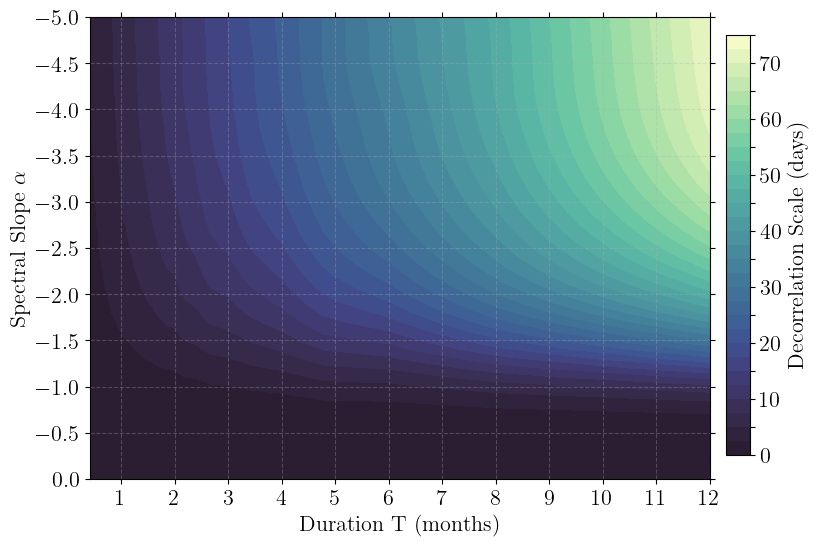

In [48]:
# Set plotting parameters
levels = np.arange(0, 75 + 2.5, 2.5)

# Create the figure
fig, ax = plt.subplots(1,1, figsize=(8, 6))

# Plot decorrelation scale
pc = ax.contourf(window_sizes_months, -1*alpha, Lt_av_days, levels=levels, cmap=cmo.deep_r)

# Set figure attributes
ax.set_xlabel('Duration T (months)')
ax.set_ylabel(r'Spectral Slope $\alpha$')
ax.set_xticks(np.arange(1,13))
ax.set_yticks(np.arange(-5, 0+0.5,0.5))
ax.set_ylim(-5,0)
ax.invert_yaxis()
ax.grid(True,linestyle='--',alpha=0.3)
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
               direction='out', which='both', length=3.5)

# Set colorbar 
cax = fig.add_axes([0.92, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'Decorrelation Scale (days)', fontsize=fontsize)
cbar.mappable.set_clim(0, 75)
ticks = np.arange(0, 75+5, 5)
cbar.set_ticks(ticks)
labels = [f'{val}' if i % 2 == 0 else '' for i, val in enumerate(ticks)]
cbar.set_ticklabels(labels)

# Save with high quality
figName = 'figS02.png'
fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

Combine all the figures together

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_26754/417527013.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


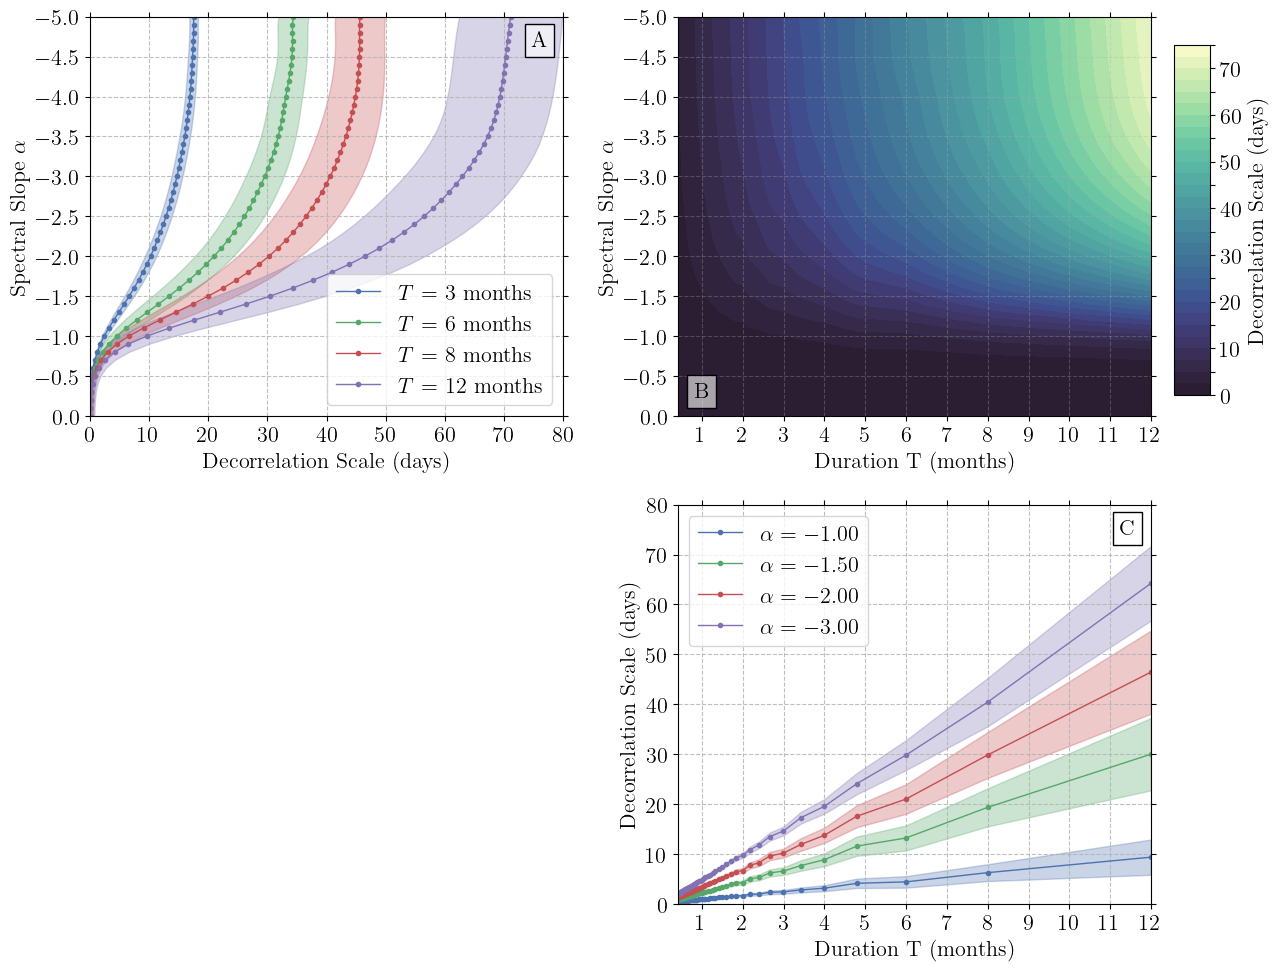

In [46]:
# Set plotting parameters
levels = np.arange(0, 75 + 2.5, 2.5)
cn = 0

# Create figure
fig,axes = plt.subplots(2,2,figsize=(12, 10))
ax1,ax2,ax3,ax4 = axes.flatten()

#--- Subplot 1 ---# 

# Loop through window sizes
for i, window in enumerate(window_sizes_months_as):

    # Plot mean decorrelation scale
    ax1.plot(Lt_av_days_as[:,i], -1*alphas_as, '.-', color=colors_decor[i],
            linewidth=1, label=r'$T$ = {:.0f} months'.format(window))
    
    # Plot standard error as shaded region
    ax1.fill_betweenx(-1*alphas_as,
                     Lt_av_days_as[:,i] - Lt_stdm_days_as[:,i],
                     Lt_av_days_as[:,i] + Lt_stdm_days_as[:,i],
                     color=colors_decor[i], alpha=0.3)

# Set figure attributes
ax1.set_xlabel('Decorrelation Scale (days)')
ax1.set_xticks(np.arange(0,80 + 10,10))
ax1.set_xlim(0,80)
ax1.set_ylabel(r'Spectral Slope $\alpha$')
ax1.set_yticks(np.arange(-5, 0+0.5,0.5))
ax1.set_ylim(-5,0)
ax1.invert_yaxis()
ax1.grid(True,linestyle='--',alpha=0.8)
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.legend(loc='lower right', fontsize=fontsize)

#--- Subplot 2 ---# 

# Plot decorrelation scale
pc = ax2.contourf(window_sizes_months, -1*alpha, Lt_av_days, levels=levels, cmap=cmo.deep_r)

# Set figure attributes
ax2.set_xlabel('Duration T (months)')
ax2.set_ylabel(r'Spectral Slope $\alpha$')
ax2.set_xticks(np.arange(1,13))
ax2.set_yticks(np.arange(-5, 0+0.5,0.5))
ax2.set_ylim(-5,0)
ax2.invert_yaxis()
ax2.grid(True,linestyle='--',alpha=0.3)
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
               direction='out', which='both', length=3.5)

# Set colorbar 
cax = fig.add_axes([0.99, 0.59, 0.03, 0.35])  # [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'Decorrelation Scale (days)', fontsize=fontsize)
cbar.mappable.set_clim(0, 75)
ticks = np.arange(0, 75+5, 5)
cbar.set_ticks(ticks)
labels = [f'{val}' if i % 2 == 0 else '' for i, val in enumerate(ticks)]
cbar.set_ticklabels(labels)

#--- Subplot 3 ---# 
ax3.axis('off')

#--- Subplot 4 ---# 

# Loop through spectral slopes
for i, ialpha in enumerate(alpha_ws):
    
    # Plot just spectral slopes of 1, 1.5, 2, and 3
    if (ialpha == 1) | (ialpha == 1.5) | (ialpha == 2) | (ialpha == 3): 

        # Plot mean decorrelation scale
        ax4.plot(window_sizes_months_ws, Lt_av_days_ws[i, :], '.-', color=colors_decor[cn],
                linewidth=1, label=r'$\alpha = -${:.2f}'.format(ialpha))
        
        # Plot standard error as shaded region
        ax4.fill_between(window_sizes_months_ws,
                        Lt_av_days_ws[i, :] - Lt_stdm_days_ws[i, :],
                        Lt_av_days_ws[i, :] + Lt_stdm_days_ws[i, :],
                        color=colors_decor[cn], alpha=0.3)

        # Reset counter 
        cn += 1

# Set figure attributes
ax4.set_xlabel('Duration T (months)')
ax4.set_ylabel(r'Decorrelation Scale (days)')
ax4.set_xlim(np.min(window_sizes_months_ws), np.max(window_sizes_months_ws))
ax4.set_xticks(np.arange(1,13))
ax4.set_yticks(np.arange(0,80 + 10,10))
ax4.set_ylim(0,80)
ax4.grid(True,linestyle='--',alpha=0.8)
ax4.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax4.legend(loc='upper left', fontsize=fontsize)

# Label each subplot
pos = [0.95, 0.94]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, [0.05,0.06], 'B', fontsize = fontsize)
add_corner_label(ax4, pos, 'C', fontsize = fontsize)

# Adjust spacing
plt.tight_layout()
plt.show()

# Save with high quality
figName = 'fig02.png'
fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

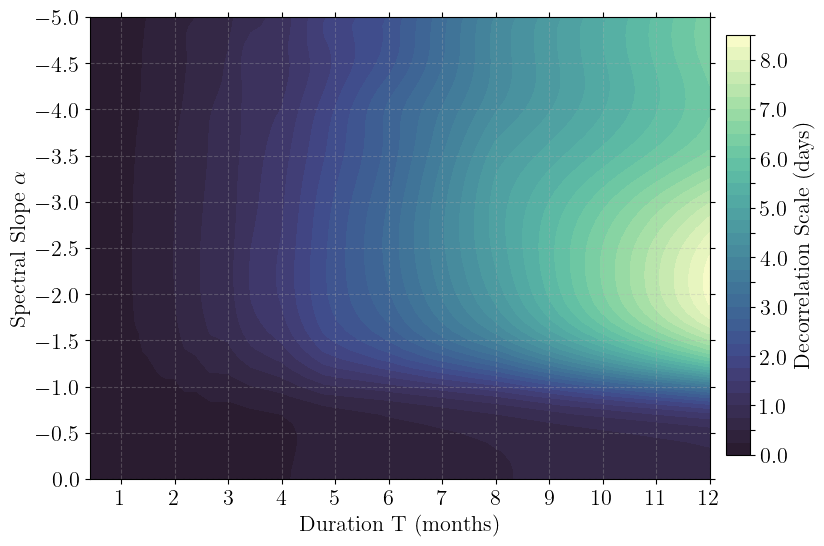

In [47]:
# Set plotting parameters
levels = np.arange(0, 8.5 + 0.25, 0.25)

# Create the figure
fig, ax = plt.subplots(1,1, figsize=(8, 6))

# Plot decorrelation scale
cn = ax.contourf(window_sizes_months, -1*alpha, Lt_stdm_days, levels=levels, cmap=cmo.deep_r)

# Set figure attributes
ax.set_xlabel('Duration T (months)')
ax.set_ylabel(r'Spectral Slope $\alpha$')
ax.set_xticks(np.arange(1,13))
ax.set_yticks(np.arange(-5, 0+0.5,0.5))
ax.set_ylim(-5,0)
ax.invert_yaxis()
ax.grid(True,linestyle='--',alpha=0.3)
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
               direction='out', which='both', length=3.5)

# Set colorbar 
cax = fig.add_axes([0.92, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(cn, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'Decorrelation Scale (days)', fontsize=fontsize)
cbar.mappable.set_clim(0, 8.5)
ticks = np.arange(0, 8.5+0.5, 0.5)
cbar.set_ticks(ticks)
labels = [f'{val}' if i % 2 == 0 else '' for i, val in enumerate(ticks)]
cbar.set_ticklabels(labels)

# Save with high quality
figName = 'figS01.png'
fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

Fit a linear trend to each of the lines 

In [66]:
np.shape(Lt_av_days)
np.shape(alpha)
np.shape(window_sizes_months)
print(n_windows)
alpha = np.arange(0,5 + 0.1,0.1)  # Prescribed spectral slopes

57


In [55]:
# Initialize arrays
dfit = np.zeros((n_alpha, n_windows))

# Loop through spectral slopes 
for i in range(0,n_alpha):
    
    # Preform linear fit
    dfit[i,:], *_ = unweighted_lsf(Lt_av_days[i, :], window_sizes_months, parameters=0, freqs=None, sigma=None)

Replot with linear fits

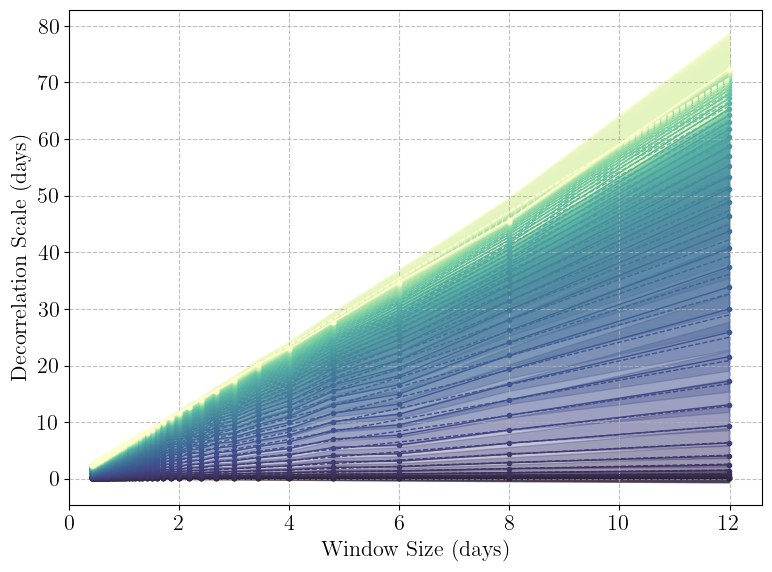

In [77]:
# Set parameters
colors = cmo.deep_r(np.linspace(0, 1, len(alpha)))

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through spectral slopes
for i, ialpha in enumerate(alpha):

    # Plot mean decorrelation scale
    ax.plot(window_sizes_months, Lt_av_days[i, :], '.-', color=colors[i],
            linewidth=1, label=r'$\alpha$ = {:.1f}'.format(ialpha))
    
    # Plot the linear fit to the decorrelation scale vs. window size relation
    ax.plot(window_sizes_months, dfit[i, :], '--', color=colors[i],
            linewidth=1)
    
    # Plot standard error as shaded region
    ax.fill_between(window_sizes_months,
                     Lt_av_days[i, :] - Lt_stdm_days[i, :],
                     Lt_av_days[i, :] + Lt_stdm_days[i, :],
                     color=colors[i], alpha=0.3)

# Set figure attributes
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xlabel('Window Size (days)')
ax.set_xlim(0, np.max(window_sizes_months) * 1.05)
ax.grid(True,linestyle='--',alpha=0.8)
#ax.legend(loc='lower right', fontsize=fontsize)

# Display figure
plt.tight_layout()
plt.show()

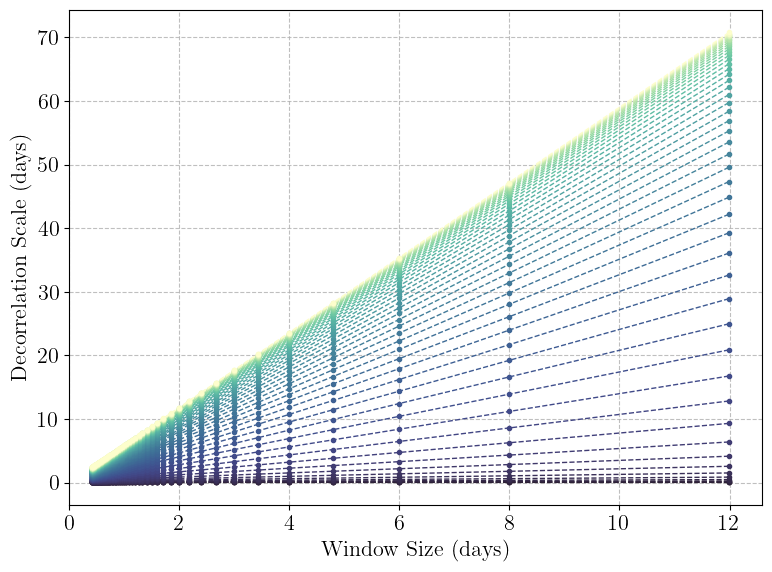

In [70]:
# Set parameters
colors = cmo.deep_r(np.linspace(0, 1, len(alpha)))

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through spectral slopes
for i, ialpha in enumerate(alpha):
    
    # Plot the linear fit to the decorrelation scale vs. window size relation
    ax.plot(window_sizes_months, dfit[i, :], '.--', color=colors[i],
            linewidth=1, label=r'$\alpha$ = {:.1f}'.format(ialpha))
    
# Set figure attributes
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xlabel('Window Size (days)')
ax.set_xlim(0, np.max(window_sizes_months) * 1.05)
ax.grid(True,linestyle='--',alpha=0.8)
#ax.legend(loc='lower right', fontsize=fontsize)

# Display figure
plt.tight_layout()
plt.show()

Save data from linear fit into a npz file

In [ ]:
# Set the path to direction for saving data 
PATH = ROOT + 'AirSeaCoupling/data/synthetic/'

# Set file path and name
file_path = PATH + "decorrelation_window_size_fit.npz"

# Remove file if file already exists
if os.path.exists(file_path):
    os.remove(file_path)

# Set metadata
metadata = {
    'description': 'Temporal decorrelation scales from idealized simulations of red spectra with prescribed spectral slope. ',
    'source': 'Synthetic data (2 years of hourly data) ensemble avergaed over 10 random seeds.',
    'coordinates units': '1 hr'
}

# Save data arrays and metadata to a .npz file
np.savez(file_path, 
        Lt_av          = Lt_av_days,           # Units: days
        Lt_stdm        = Lt_stdm_days,         # Units: days
        Lt_av_as       = Lt_av_days_as         # Units: days 
        Lt_stdm_as     = Lt_stdm_days_as       # Units: days
        Lt_av_ws       = Lt_av_days_ws         # Units: days 
        Lt_stdm_ws     = Lt_stdm_days_ws       # Units: days
        Lt_fit         = dfit,                 # Units: days         
        scales         = window_sizes_months,  # Units: months
        scales_as      = window_sizes_months_as # Units: months
        scales_ws      = window_sizes_months_ws # Units: months
        alpha          = alpha,
        metadata       = metadata
        )

In [ ]:
Lt_av_days_as = Lt_av_ens * (1/24)
Lt_stdm_days_as = Lt_stdm_ens * (1/24)
window_sizes_months_as = window_sizes / (24 * 30.44)